In [1]:
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [7]:
from google.colab import files
uploaded=files.upload()

Saving HR_comma_sep.csv to HR_comma_sep.csv


In [8]:
df = pd.read_csv('/content/HR_comma_sep.csv')

In [9]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


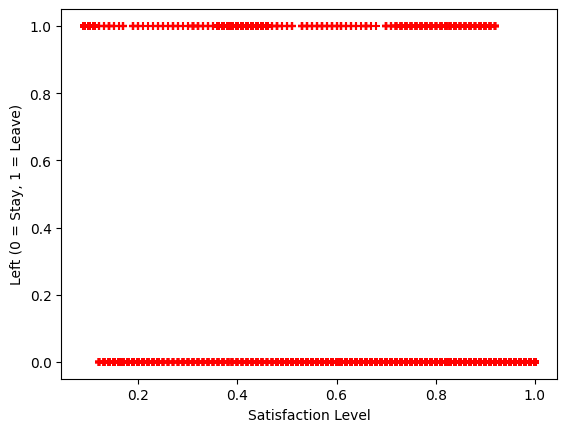

In [11]:
plt.scatter(df.satisfaction_level, df.left, marker='+', color='red')
plt.xlabel("Satisfaction Level")
plt.ylabel("Left (0 = Stay, 1 = Leave)")
plt.show()

In [12]:
df.groupby('left').mean(numeric_only=True)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
left,,,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032,0.175009,0.026251
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,0.005321


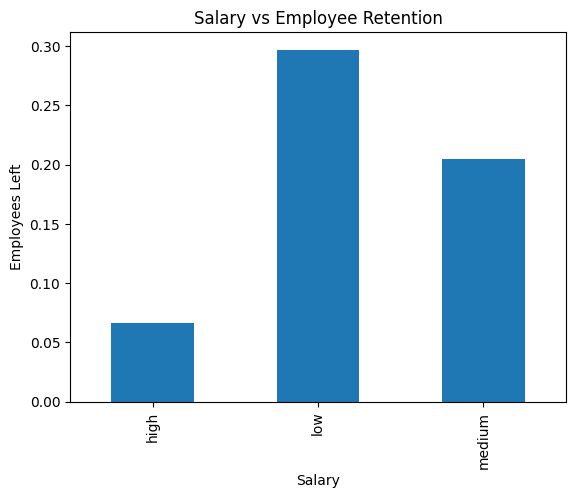

In [13]:
df.groupby('salary')['left'].mean().plot(kind='bar')

plt.title("Salary vs Employee Retention")
plt.xlabel("Salary")
plt.ylabel("Employees Left")
plt.show()

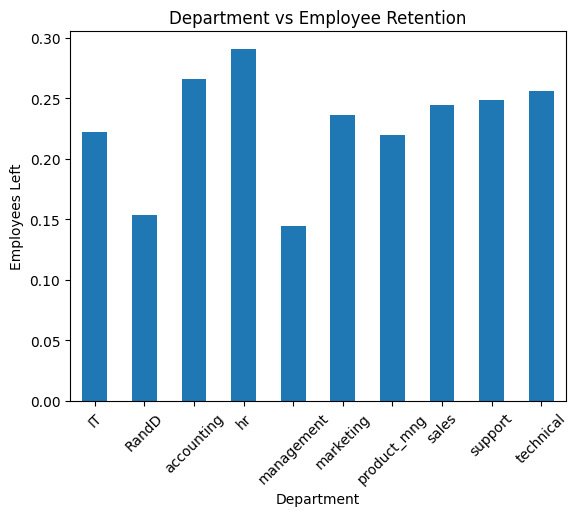

In [14]:
df.groupby('Department')['left'].mean().plot(kind='bar')

plt.title("Department vs Employee Retention")
plt.xlabel("Department")
plt.ylabel("Employees Left")
plt.xticks(rotation=45)

plt.show()

In [15]:
X = df[['satisfaction_level',
        'average_montly_hours',
        'promotion_last_5years',
        'salary']]

y = df.left

In [16]:
X = pd.get_dummies(X, drop_first=True)

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [21]:
prediction = model.predict(X_test)

print(prediction)

[0 0 0 ... 0 0 0]


In [22]:
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.762
